# Similarity

test set 里两两配对，算 embedding 的 cosine similarity 跟参数差，看相关性。

假如 embedding 真的编码了某个声学参数，那 embedding 越像 -> 参数差应该越小 -> 负相关。

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
if not os.path.exists('analysis') and os.path.exists('utils.py'):
    os.chdir('..')
sys.path.insert(0, os.path.abspath('analysis'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from utils import load_embeddings, load_continuous_labels, TARGET_NAMES, is_csv_aligned

ENCODERS = ['baseline', 'bewo']
rng = np.random.default_rng(0)

df = load_continuous_labels('test')
cont = df[['DRR', 'C80', 'RT60', 'ILD', 'ITD_ms']].to_numpy(dtype=np.float32)

In [2]:
# 算 pair 数据：sample 一万对就够了
def pair_data(emb, max_pairs=10000):
    n = emb.shape[0]
    iu = np.triu_indices(n, k=1)
    if iu[0].size > max_pairs:
        sel = rng.choice(iu[0].size, size=max_pairs, replace=False)
        iu = (iu[0][sel], iu[1][sel])
    sims = cosine_similarity(emb)[iu]
    diffs = {}
    for i, t in enumerate(TARGET_NAMES):
        diffs[t] = np.abs(cont[iu[0], i] - cont[iu[1], i])
    return sims, diffs

In [3]:
rows = []
all_pairs = {}
for enc in ENCODERS:
    emb, cls = load_embeddings(enc, 'test')
    if not is_csv_aligned(cls, df):
        print(enc, 'test 没对齐 - 跳过')
        continue
    sims, diffs = pair_data(emb)
    all_pairs[enc] = (sims, diffs)
    for t, d in diffs.items():
        rows.append({
            'encoder': enc,
            'target': t,
            'spearman': round(spearmanr(sims, d).statistic, 3),
            'pearson': round(pearsonr(sims, d).statistic, 3),
        })

corr = pd.DataFrame(rows).pivot(index='target', columns='encoder', values=['spearman', 'pearson'])
corr = corr.reindex(TARGET_NAMES)
corr

spearman         pearson       
encoder baseline   bewo baseline   bewo
target                                 
DRR       -0.671 -0.308   -0.625 -0.292
C80       -0.769 -0.605   -0.769 -0.636
RT60      -0.578 -0.731   -0.533 -0.631
ILD       -0.213  0.030   -0.101 -0.027
ITD       -0.110  0.044    0.024  0.122

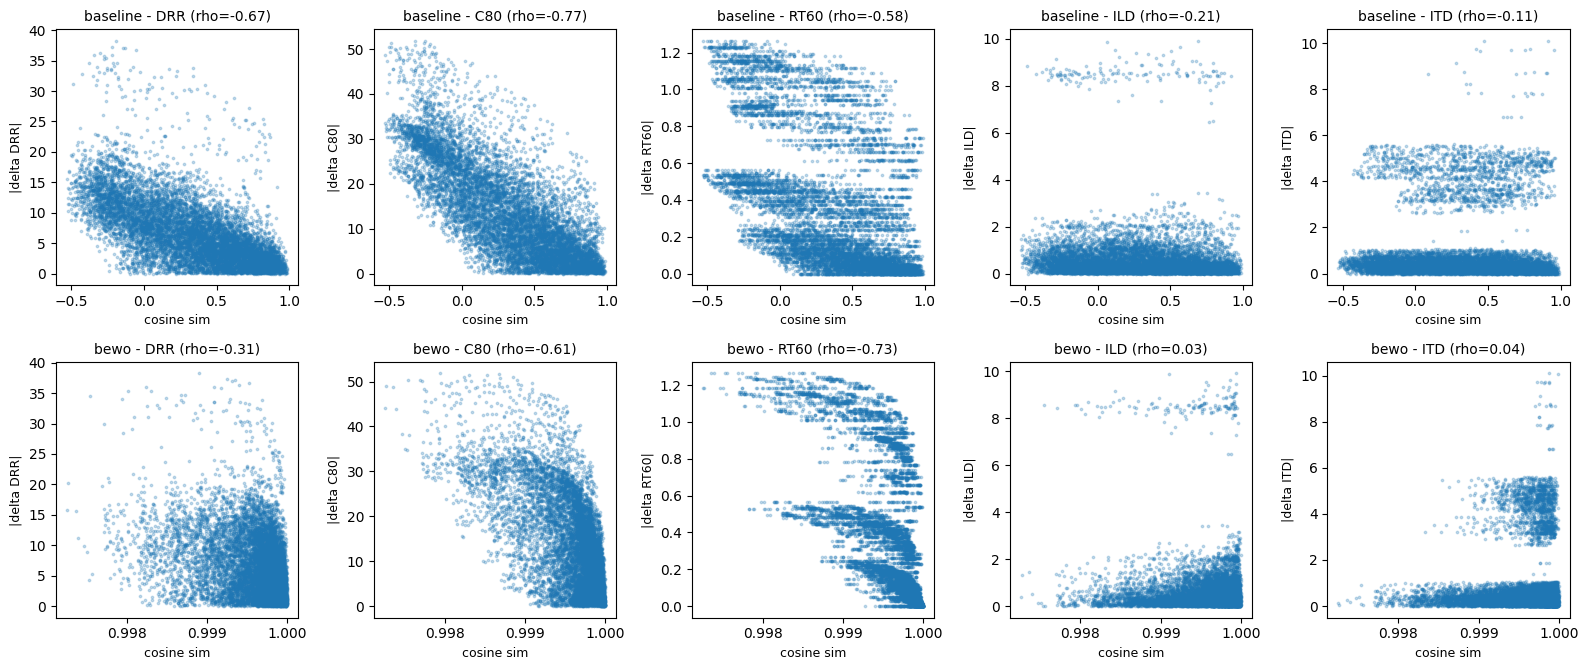

In [4]:
n = len(all_pairs)
fig, axes = plt.subplots(n, len(TARGET_NAMES), figsize=(3.2*len(TARGET_NAMES), 3.4*n))
if n == 1:
    axes = axes[None, :]

for r, (enc, (sims, diffs)) in enumerate(all_pairs.items()):
    for c, t in enumerate(TARGET_NAMES):
        sp = spearmanr(sims, diffs[t]).statistic
        axes[r, c].scatter(sims, diffs[t], s=3, alpha=0.25)
        axes[r, c].set_title(f'{enc} - {t} (rho={sp:.2f})', fontsize=10)
        axes[r, c].set_xlabel('cosine sim', fontsize=9)
        axes[r, c].set_ylabel(f'|delta {t}|', fontsize=9)

plt.tight_layout()
plt.savefig('analysis/figs/02_similarity.png', dpi=120, bbox_inches='tight')
plt.show()

rho 越负越好。

DRR/C80/RT60 都是显著的负相关，但 ILD/ITD 几乎接近 0，跟 decodability 那边的发现一致。